In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../../../data/01-anomaly-detection-agent-spec")


def load_pool(name, kind="real"):
    """Load a pool and its metadata by name, e.g. load_pool("R1"), load_pool("S1", "synthetic").

    kind: "real" | "synthetic" | "full"
    """
    base = DATA / kind
    return pd.read_parquet(base / f"{name}.parquet"), pd.read_parquet(base / f"{name}_metadata.parquet")


def pick(meta, n=5, anomalous=None, anomaly_type=None, base_type=None, dataset=None,
         split=None, min_ratio=None, max_ratio=None, sort_by=None, random_state=None):
    """Select series ids from a metadata frame by whatever filters are relevant.

    anomalous     - True/False to keep only dirty/clean series (None = both)
    anomaly_type  - synthetic pools: "point", "group", "flatline", ...
    base_type     - synthetic pools: "ar1", "trend_seasonal", ...
    dataset       - real pools: "YAHOO", "MITDB", ...
    split         - "dev" | "test"
    min_ratio/max_ratio - bounds on the share of anomalous points in the series
    sort_by       - metadata column to sort by, e.g. "anomaly_ratio" for the densest
    random_state  - int for a reproducible random pick instead of the first n
    """
    df = meta
    ratio_col = "anomaly_ratio" if "anomaly_ratio" in df.columns else "anomaly_fraction"
    if anomalous is not None:
        df = df[df["y_i"] == int(bool(anomalous))]
    if anomaly_type is not None:
        df = df[df["anomaly_type"] == anomaly_type]
    if base_type is not None:
        df = df[df["base_type"] == base_type]
    if dataset is not None:
        df = df[df["series_id"].str.split("__").str[1] == dataset]
    if split is not None:
        df = df[df["split"] == split]
    if min_ratio is not None:
        df = df[df[ratio_col] >= min_ratio]
    if max_ratio is not None:
        df = df[df[ratio_col] <= max_ratio]
    if df.empty:
        print("no series match these filters")
        return []
    if sort_by is not None:
        df = df.sort_values(sort_by, ascending=False)
    elif random_state is not None:
        df = df.sample(min(n, len(df)), random_state=random_state)
    return df["series_id"].head(n).tolist()


def describe(meta_row):
    """Compact tags for a series, tolerant of columns a given pool does not have."""
    if meta_row is None:
        return {}
    keys = ("anomaly_type", "base_type", "severity", "severity_effective", "detect_z",
            "period_detected", "anomaly_ratio", "anomaly_fraction", "split")
    return {k: meta_row[k] for k in keys if k in meta_row and pd.notna(meta_row[k])}


def plot_series(pool, series_id, metadata=None, start=None, end=None, figsize=(14, 4)):
    """Plot one series, marking its labelled anomalous points."""
    series_df = pool[pool["series_id"] == series_id]
    if series_df.empty:
        raise ValueError(f"series {series_id!r} is not in this pool")

    # Metadata is optional: a missing row or column degrades the title, never raises.
    meta_row = None
    if metadata is not None:
        row = metadata[metadata["series_id"] == series_id]
        if not row.empty:
            meta_row = row.iloc[0].to_dict()
    tags = describe(meta_row)

    if start is not None or end is not None:
        series_df = series_df.iloc[start:end]

    x, y = series_df["time_index"], series_df["value"]
    anomalies = series_df["label"] == 1
    title = f"{series_id}\n{len(series_df):,} points | {int(anomalies.sum())} anomalous ({anomalies.mean():.2%})"
    if tags:
        title += " | " + ", ".join(f"{k}={v}" for k, v in tags.items())
    # The same text as the in-image title, but selectable/searchable above the figure.
    print(title.replace("\n", " | "))

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x, y, color="steelblue", linewidth=1.0, label="value", zorder=1)
    if anomalies.any():
        ax.scatter(x[anomalies], y[anomalies], color="red", s=12, zorder=2, label="anomaly")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("time_index"); ax.set_ylabel("value")
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show(); plt.close(fig)


def show(pool, meta, **kwargs):
    """pick() the matching series and plot each one. Every pick() filter works here."""
    start = kwargs.pop("start", None)
    end = kwargs.pop("end", None)
    figsize = kwargs.pop("figsize", (14, 4))
    for series_id in pick(meta, **kwargs):
        plot_series(pool, series_id, metadata=meta, start=start, end=end, figsize=figsize)


In [3]:
# R1 - IT-Ops pool. Loaded once; every plot below reuses these frames.
r1, r1_meta = load_pool("R1")
print(f"R1: {len(r1_meta)} series, {r1_meta.y_i.mean():.1%} anomalous, "
      f"dev/test = {(r1_meta.split == 'dev').sum()}/{(r1_meta.split == 'test').sum()}")
print("source datasets:", r1_meta.series_id.str.split("__").str[1].value_counts().to_dict())


R1: 2900 series, 25.0% anomalous, dev/test = 870/2030
source datasets: {'Exathlon': 1441, 'WSD': 807, 'IOPS': 292, 'SMD': 285, 'YAHOO': 64, 'NEK': 11}


R1__Exathlon__10_3_1000000_75.test_col_0_chunk14 | 1,500 points | 120 anomalous (8.00%) | period_detected=30.0, anomaly_ratio=0.08, split=test


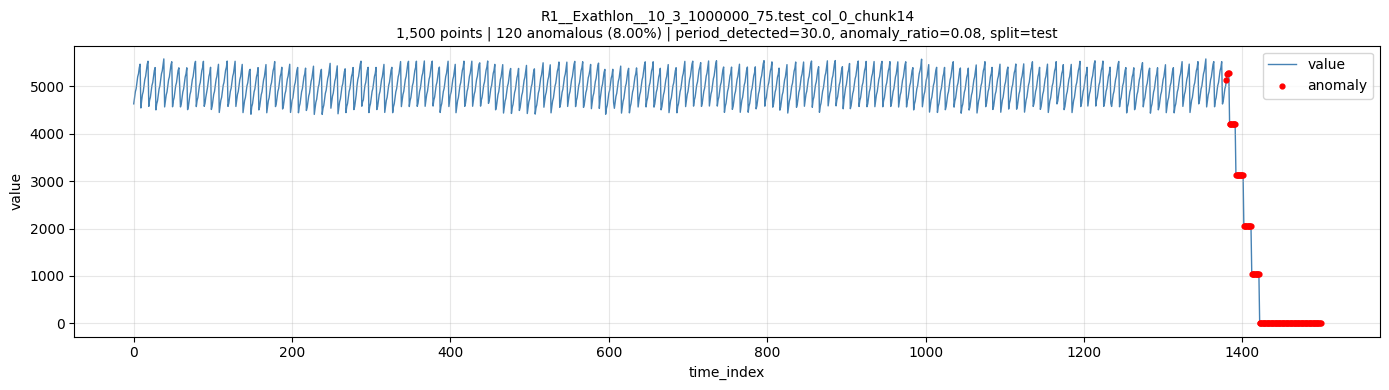

R1__Exathlon__10_3_1000000_75.test_col_1_chunk14 | 1,500 points | 118 anomalous (7.87%) | period_detected=30.0, anomaly_ratio=0.0787, split=test


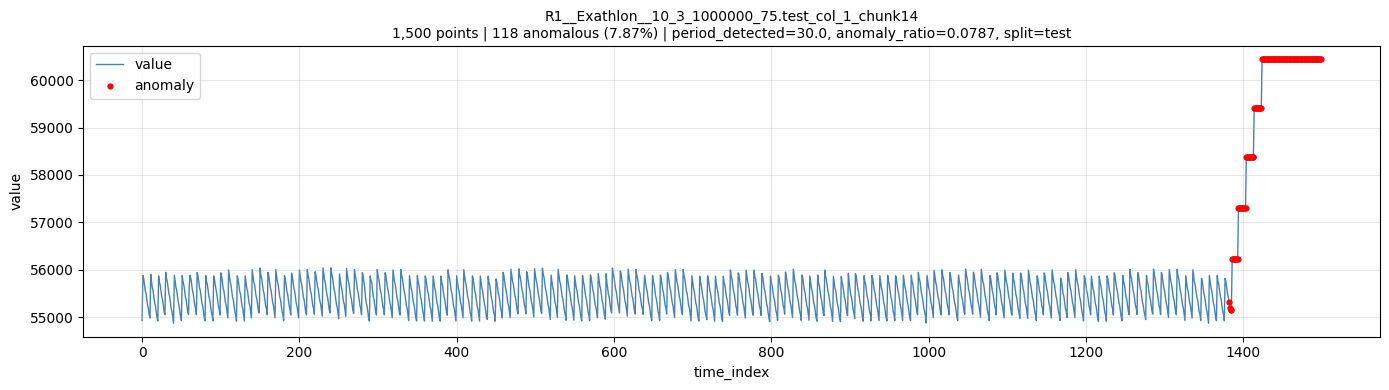

R1__Exathlon__10_3_1000000_75.test_col_2_chunk14 | 1,500 points | 331 anomalous (22.07%) | period_detected=30.0, anomaly_ratio=0.2207, split=test


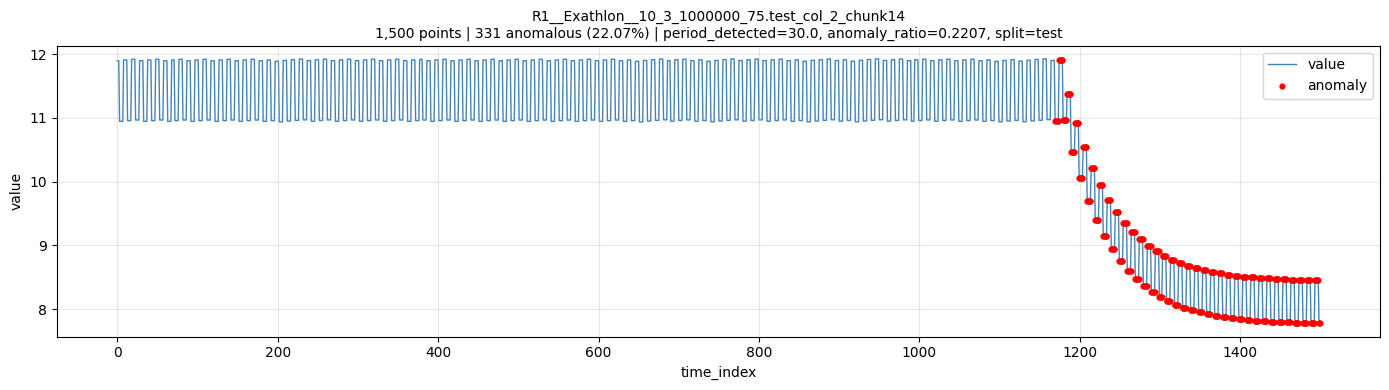

R1__IOPS__KPI-1_full | 8,784 points | 71 anomalous (0.81%) | period_detected=288.0, anomaly_ratio=0.0081, split=test


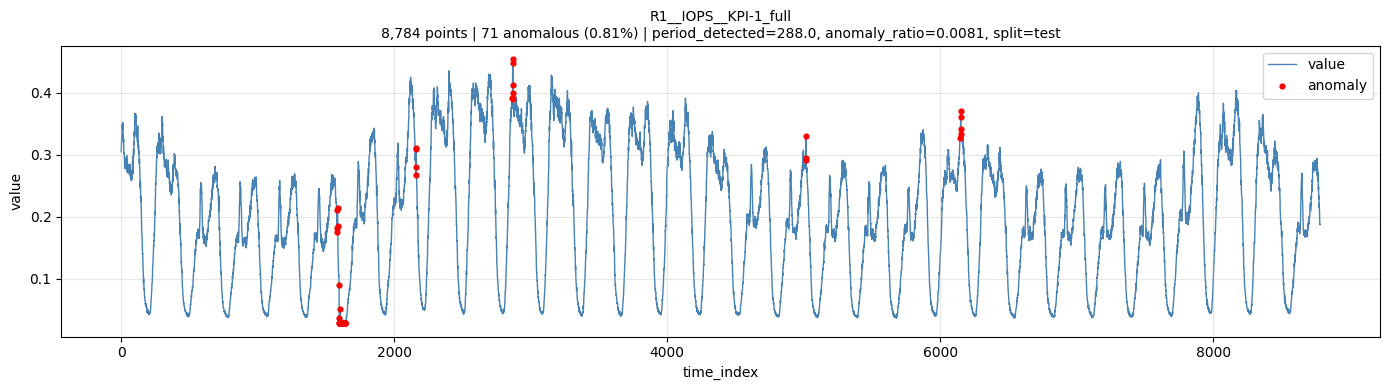

R1__IOPS__KPI-10_chunk0 | 4,320 points | 2 anomalous (0.05%) | period_detected=1440.0, anomaly_ratio=0.0005, split=test


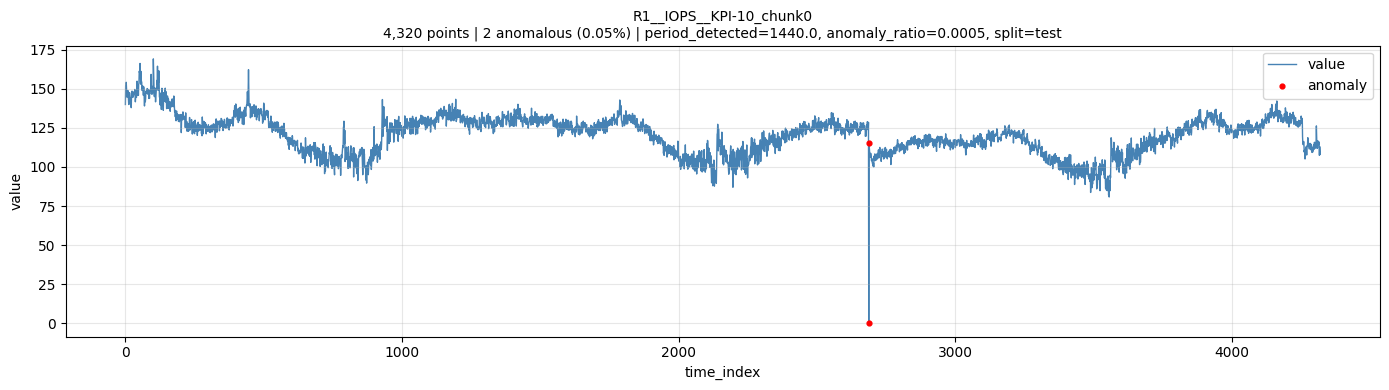

R1__IOPS__KPI-10_chunk4 | 4,320 points | 110 anomalous (2.55%) | period_detected=1440.0, anomaly_ratio=0.0255, split=test


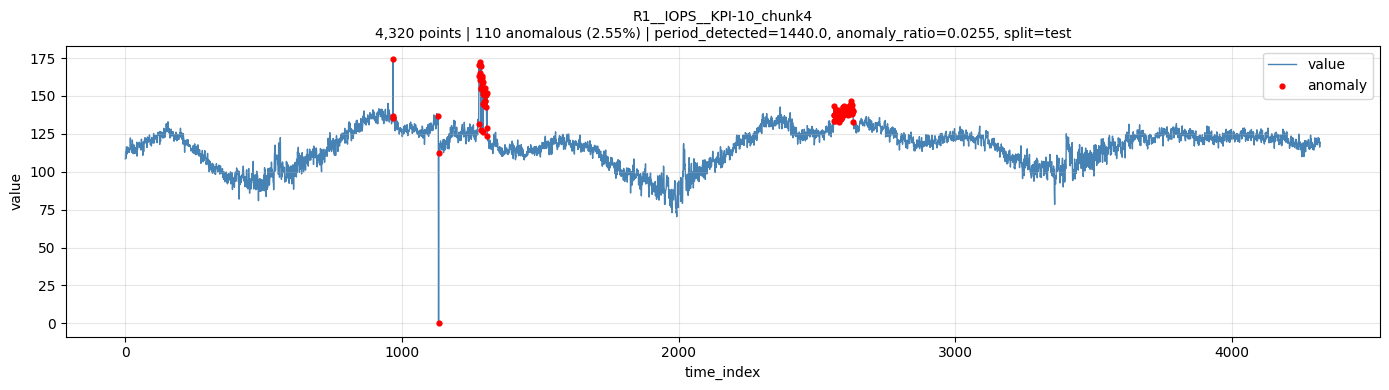

R1__NEK__NEK_0_full | 1,073 points | 73 anomalous (6.80%) | anomaly_ratio=0.068, split=test


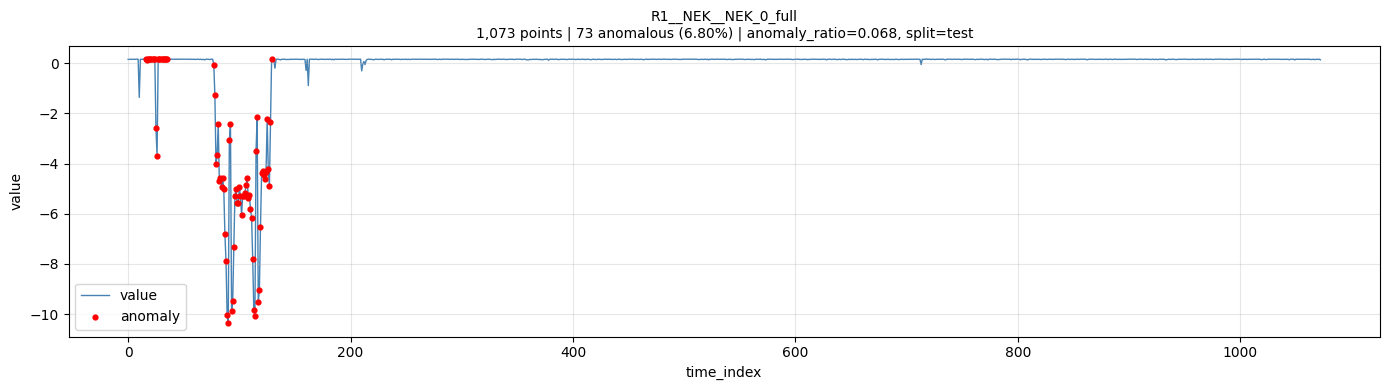

R1__NEK__NEK_12_full | 1,073 points | 89 anomalous (8.29%) | period_detected=48.0, anomaly_ratio=0.0829, split=test


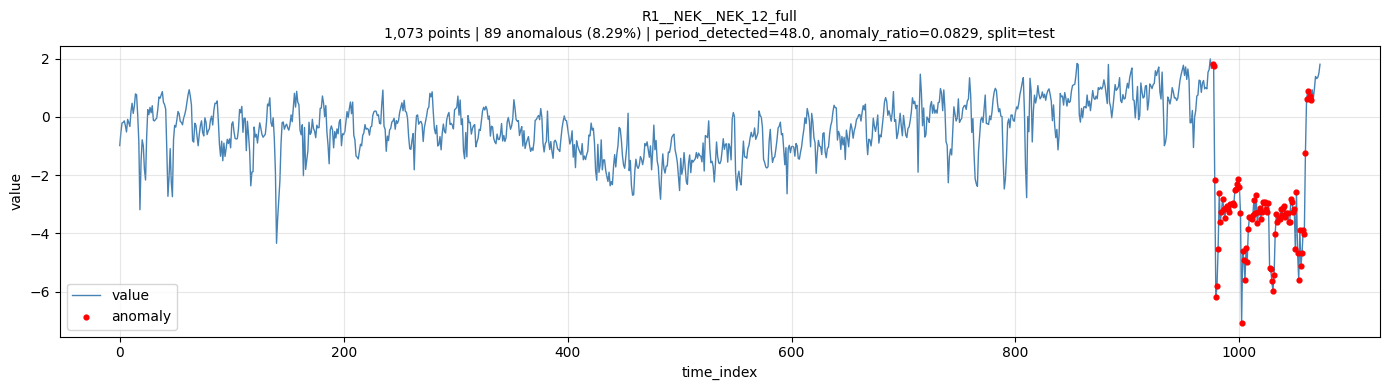

R1__NEK__NEK_2_full | 1,073 points | 90 anomalous (8.39%) | period_detected=48.0, anomaly_ratio=0.0839, split=dev


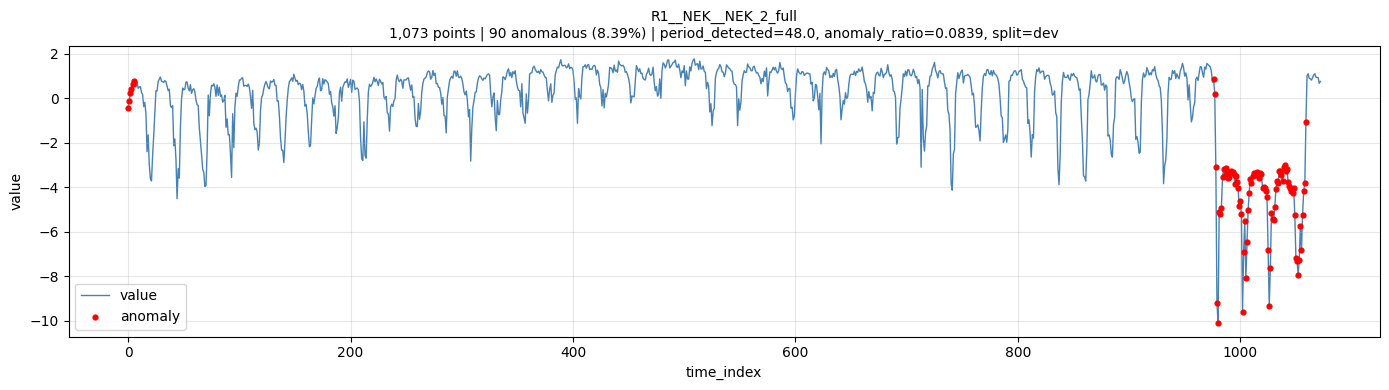

R1__SMD__processed_test_machine-1-1_col_11_chunk3 | 4,305 points | 803 anomalous (18.65%) | period_detected=1435.0, anomaly_ratio=0.1865, split=test


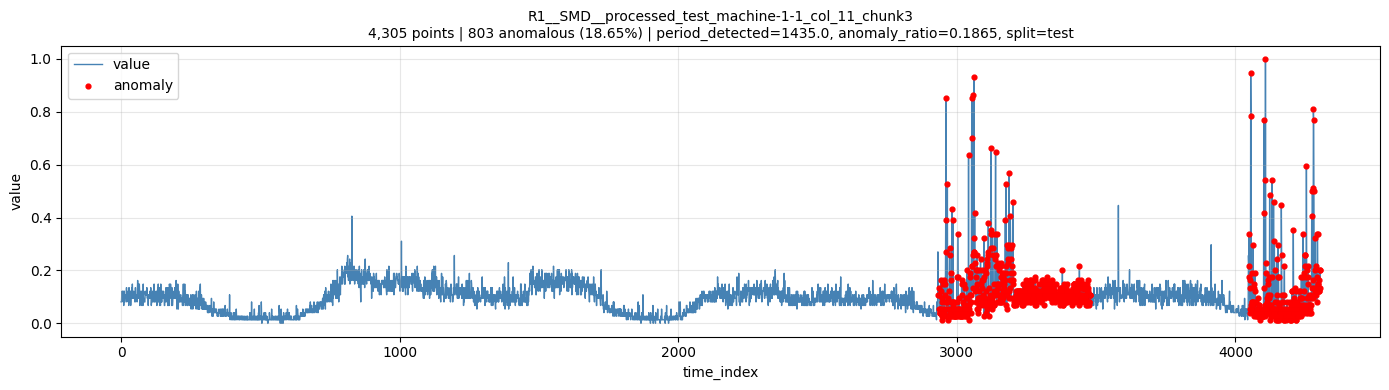

R1__SMD__processed_test_machine-1-1_col_11_chunk5 | 4,305 points | 3 anomalous (0.07%) | period_detected=1435.0, anomaly_ratio=0.0007, split=test


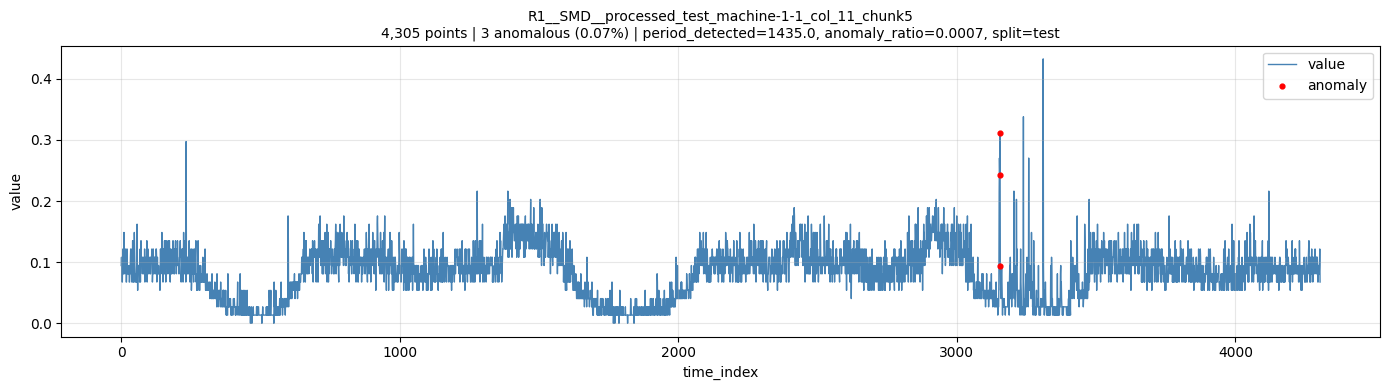

R1__SMD__processed_test_machine-1-1_col_11_chunk6 | 2,649 points | 4 anomalous (0.15%) | period_detected=1435.0, anomaly_ratio=0.0015, split=test


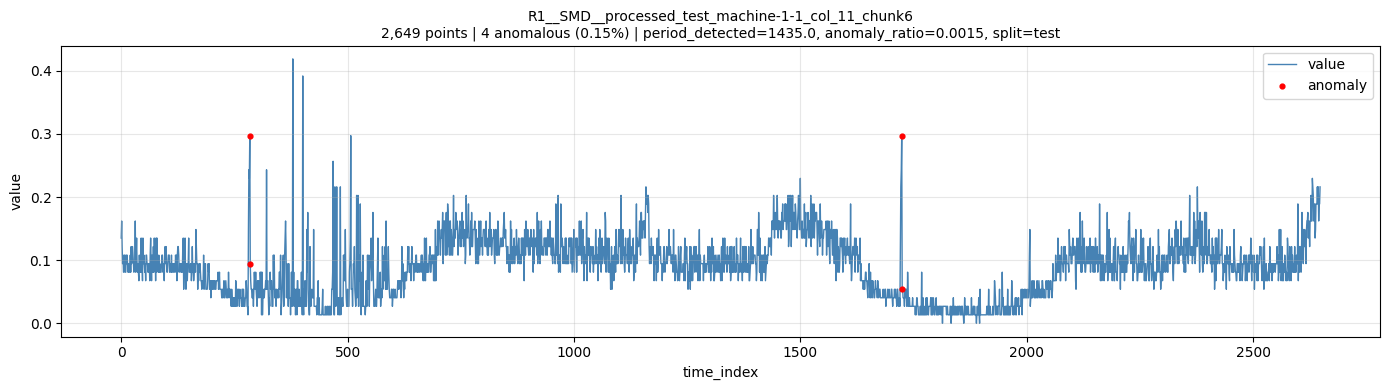

R1__WSD__WSD_10_chunk0 | 4,320 points | 71 anomalous (1.64%) | period_detected=1440.0, anomaly_ratio=0.0164, split=test


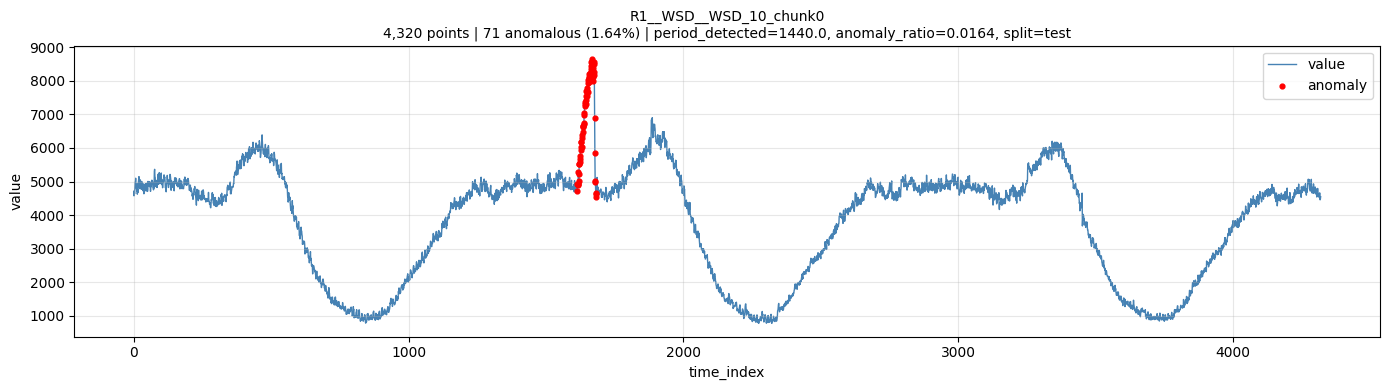

R1__WSD__WSD_101_chunk2 | 4,320 points | 26 anomalous (0.60%) | period_detected=1440.0, anomaly_ratio=0.006, split=test


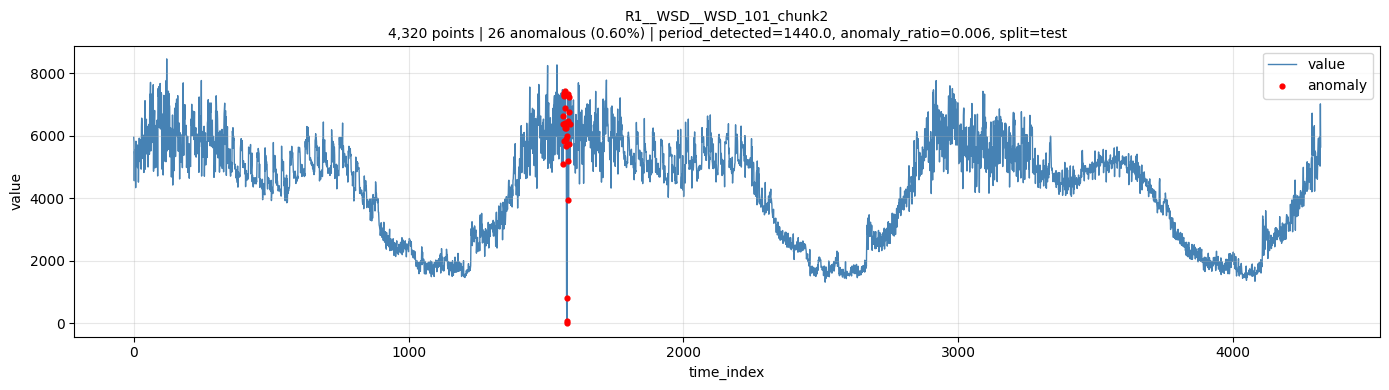

R1__WSD__WSD_102_chunk2 | 4,320 points | 12 anomalous (0.28%) | period_detected=1440.0, anomaly_ratio=0.0028, split=test


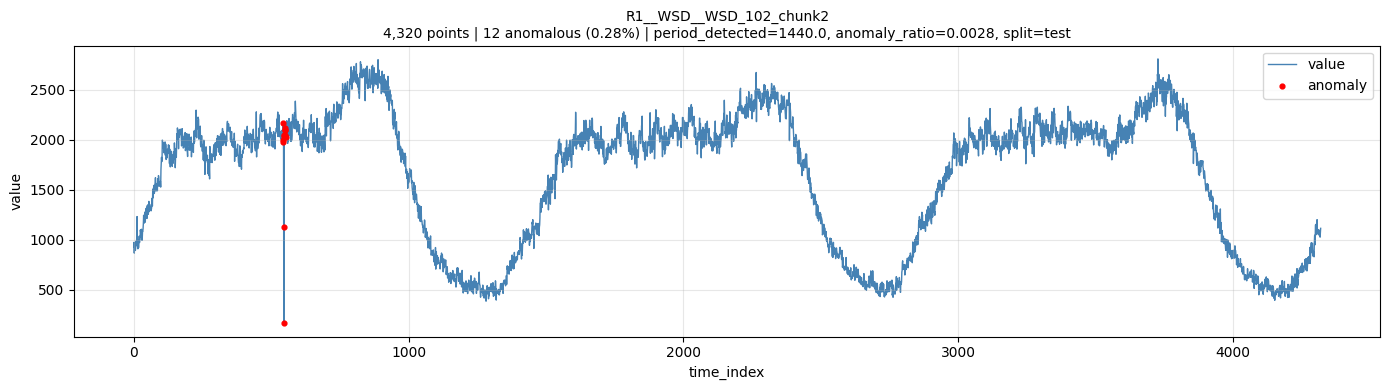

R1__YAHOO__Yahoo_A1real_10_data_full | 1,439 points | 13 anomalous (0.90%) | anomaly_ratio=0.009, split=test


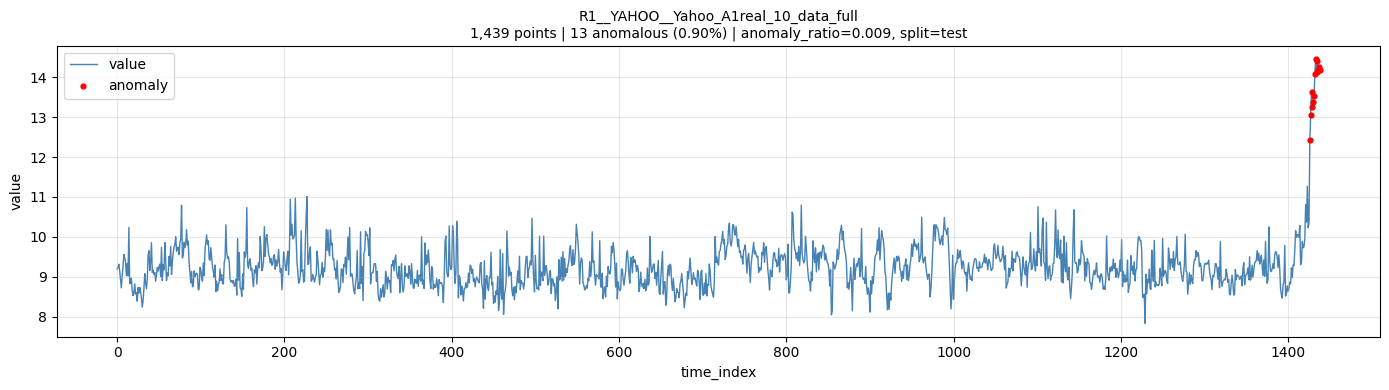

R1__YAHOO__Yahoo_A1real_11_data_full | 1,439 points | 19 anomalous (1.32%) | anomaly_ratio=0.0132, split=test


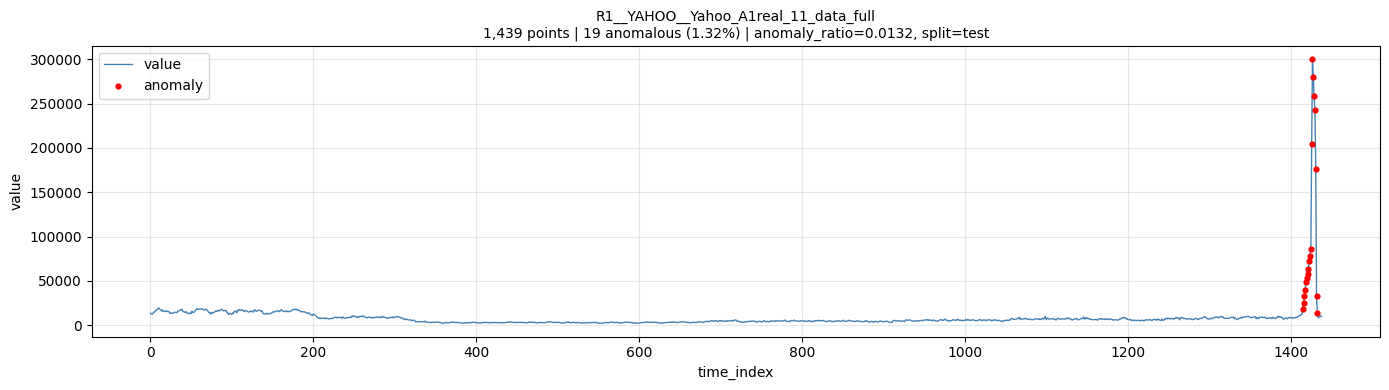

R1__YAHOO__Yahoo_A1real_12_data_full | 1,439 points | 3 anomalous (0.21%) | period_detected=288.0, anomaly_ratio=0.0021, split=dev


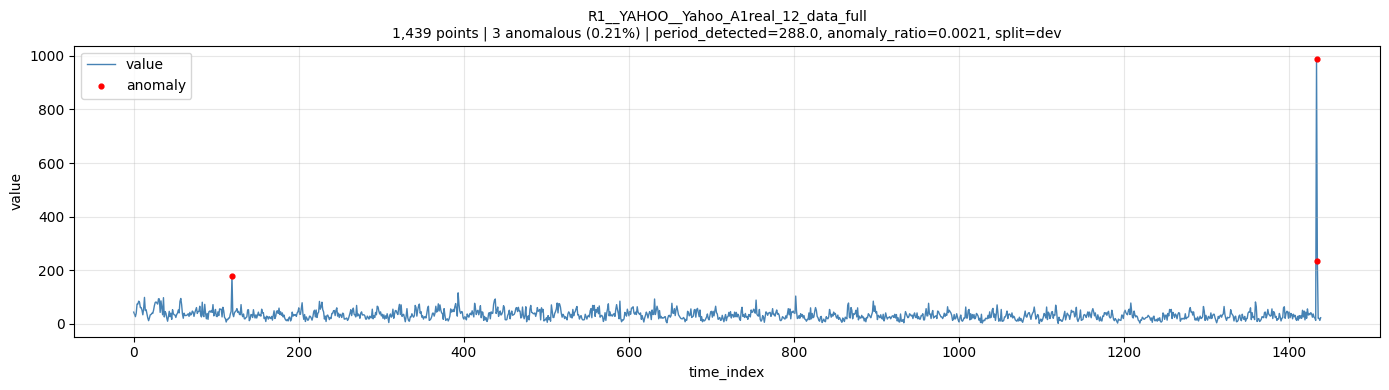

In [4]:
# Anomalous series, one per source dataset - shows how differently each domain looks.
for dataset in sorted(r1_meta.series_id.str.split("__").str[1].unique()):
    show(r1, r1_meta, n=3, anomalous=True, dataset=dataset)


R2: 2900 series, 25.0% anomalous, dev/test = 870/2030
R2__SVDB__857_col_0_chunk49 | 1,564 points | 93 anomalous (5.95%) | period_detected=92.0, anomaly_ratio=0.0595, split=test


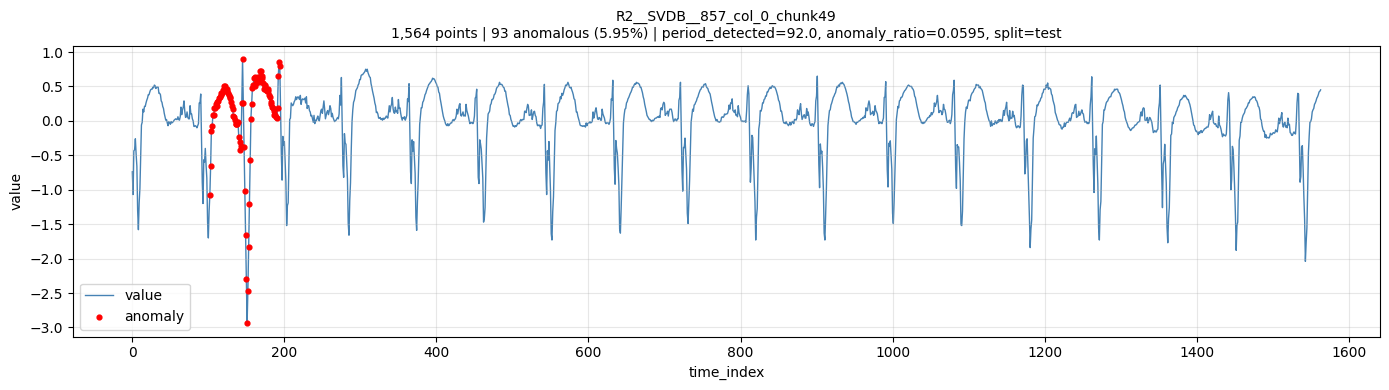

R2__SVDB__856_col_0_chunk18 | 1,539 points | 111 anomalous (7.21%) | period_detected=81.0, anomaly_ratio=0.0721, split=test


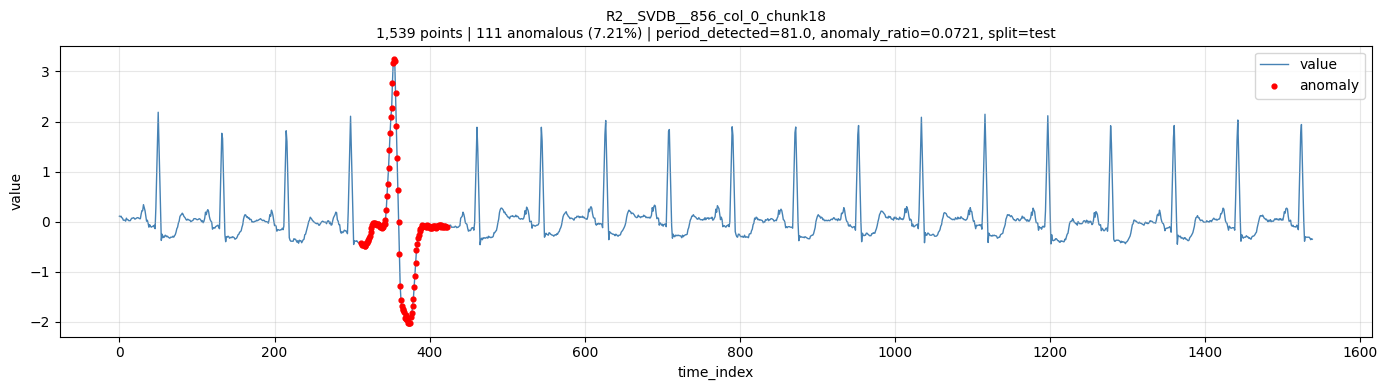

R2__SVDB__857_col_0_chunk86 | 1,564 points | 359 anomalous (22.95%) | period_detected=92.0, anomaly_ratio=0.2295, split=test


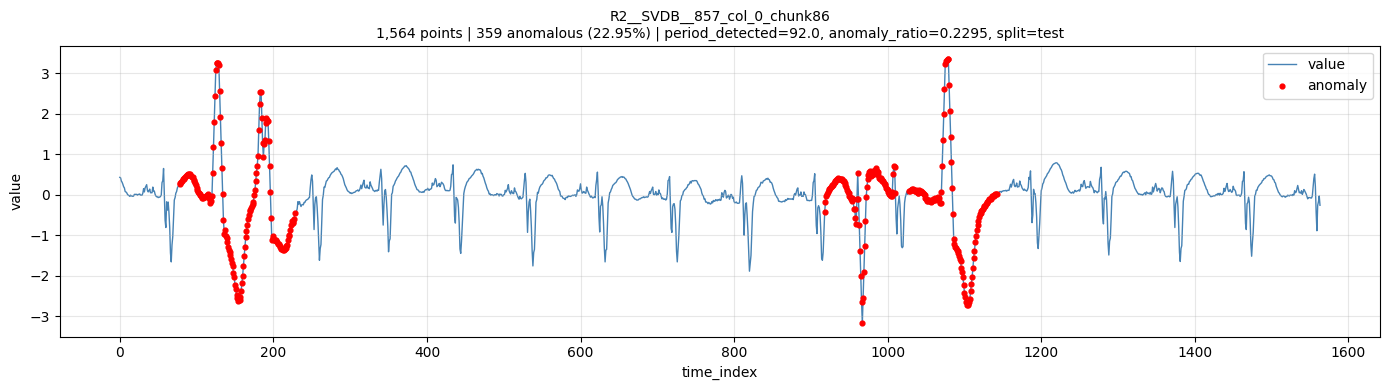

In [5]:
# R2 - biomedical (ECG) pool.
r2, r2_meta = load_pool("R2")
print(f"R2: {len(r2_meta)} series, {r2_meta.y_i.mean():.1%} anomalous, "
      f"dev/test = {(r2_meta.split == 'dev').sum()}/{(r2_meta.split == 'test').sum()}")

show(r2, r2_meta, n=3, anomalous=True, random_state=0)


R1__Exathlon__2_1_100000_60-20.test_col_1_chunk3 | 1,500 points | 0 anomalous (0.00%) | anomaly_ratio=0.0, split=test


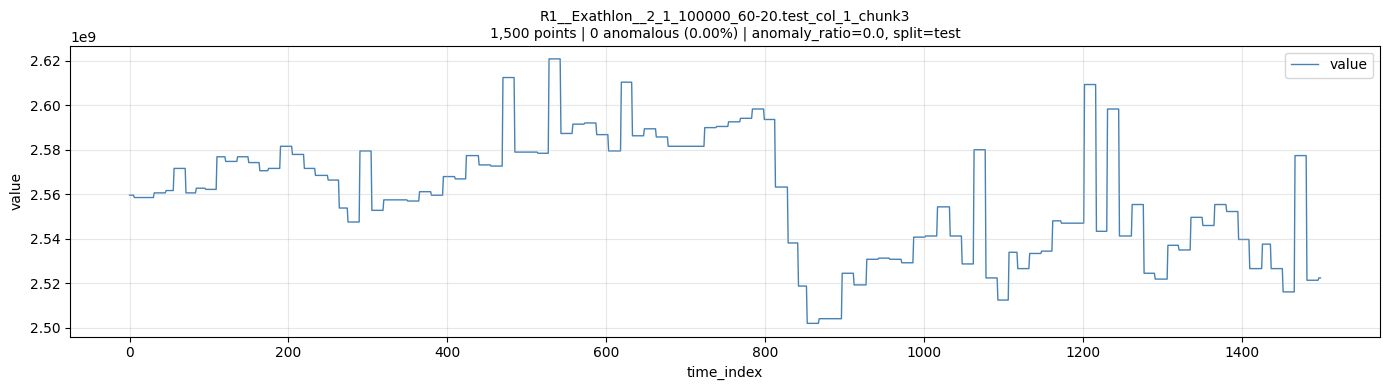

R1__YAHOO__Yahoo_A1real_64_data_full | 1,441 points | 0 anomalous (0.00%) | anomaly_ratio=0.0, split=dev


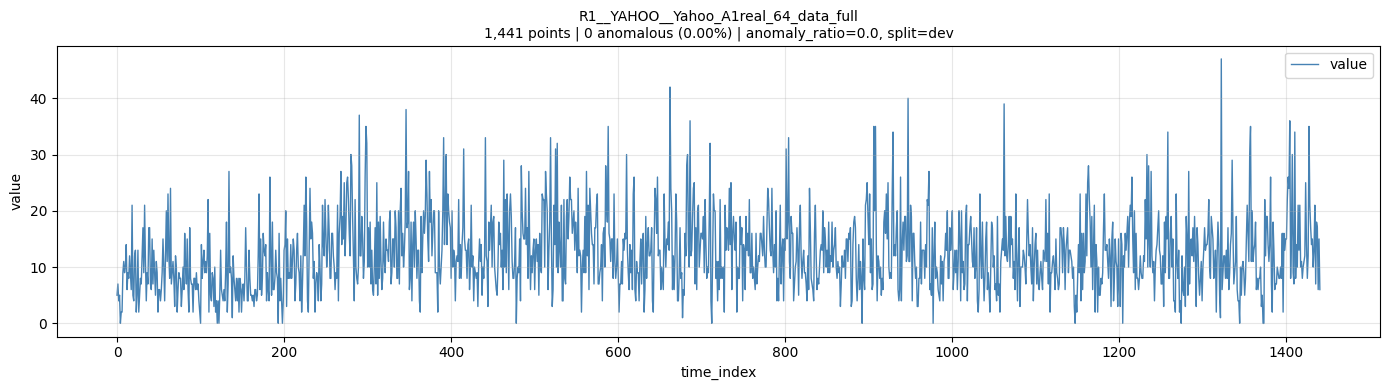

R1__Exathlon__4_1_100000_61-27.test_col_3_chunk81 | 1,500 points | 0 anomalous (0.00%) | anomaly_ratio=0.0, split=dev


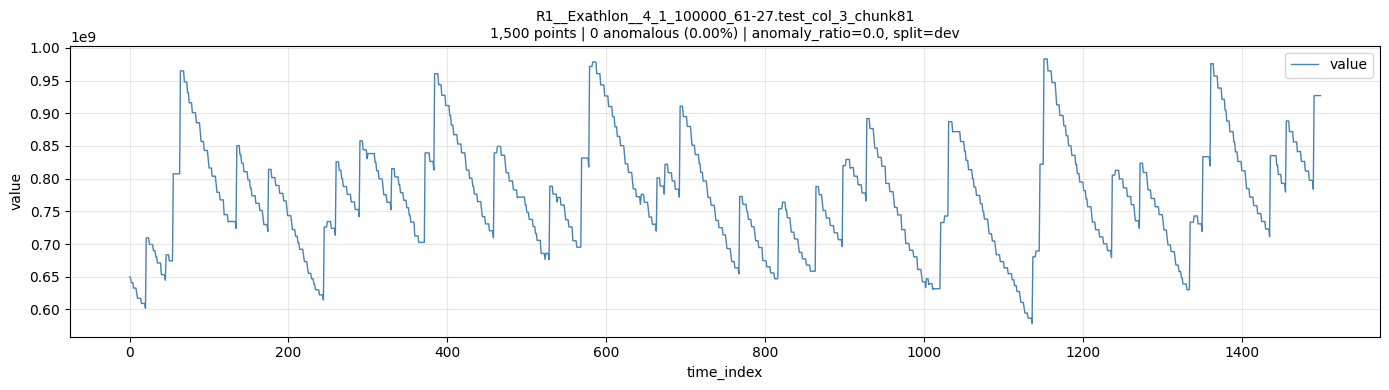

In [6]:
# Clean series - the false-positive surface a detector must stay quiet on.
show(r1, r1_meta, n=3, anomalous=False, random_state=0)


In [7]:
# Free-form exploration. Every filter is optional - mix whichever you need:
#
#   show(r1, r1_meta, n=3, dataset="YAHOO")                  # one source dataset
#   show(r1, r1_meta, n=3, split="dev")                      # one side of the split
#   show(r2, r2_meta, n=3, sort_by="anomaly_ratio")          # densest anomalies first
#   show(r1, r1_meta, n=3, max_ratio=0.005)                  # hardest: sparsest anomalies
#   show(r1, r1_meta, n=1, anomalous=True, start=0, end=400) # zoom into a window
#
# The uncomposed pools are one argument away:
#   r1_full, r1_full_meta = load_pool("R1", "full")

# show(r1, r1_meta, n=3, anomalous=True, sort_by="anomaly_ratio")